# Parte II – Regresión polinómica e interacciones


### Objetivo
Capturar efectos no lineales y de interacción utilizando ingeniería de características polinomiales y un término de sesgo explícito:
$$
\hat{L} = X @ w + b
$$




Importación de librerías

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Dataset

In [3]:
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

### 1. Visualización del conjunto de datos


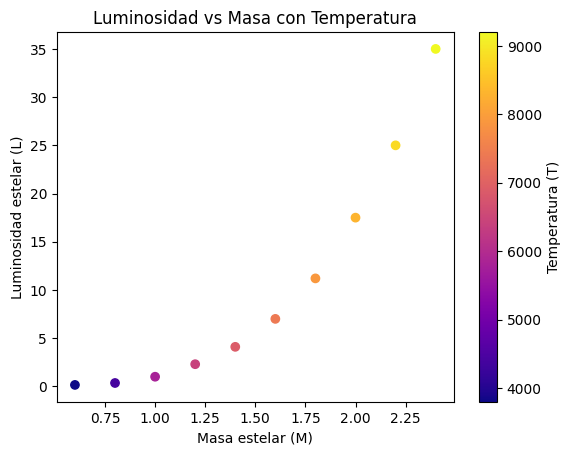

In [44]:
plt.scatter(M, L, c=T, cmap="plasma")
plt.colorbar(label="Temperatura (T)")
plt.xlabel("Masa estelar (M)")
plt.ylabel("Luminosidad estelar (L)")
plt.title("Luminosidad vs Masa con Temperatura")
plt.show()

Para una misma masa estelar, la luminosidad varía con la temperatura,
lo que indica que la masa por sí sola no explica completamente el
comportamiento de L.

### 2. Ingeniería de características

In [45]:
def build_X(M, T, model="M3"):
    if model == "M1":
        return np.column_stack([M, T])
    elif model == "M2":
        return np.column_stack([M, T, M**2])
    elif model == "M3":
        return np.column_stack([M, T, M**2, M*T])


La matriz de diseño incluye términos lineales, no lineales (M²) y de interacción (M·T),
permitiendo capturar comportamientos físicos más complejos.

### 3. Función de pérdida y gradientes

Los gradientes del MSE para el modelo multivariable son:

$$
\frac{\partial J}{\partial w} = -\frac{2}{n} X^{T} (L - \hat{y})
$$

$$
\frac{\partial J}{\partial b} = -\frac{2}{n} \sum (L - \hat{y})
$$

Se utiliza el error cuadrático medio (MSE) como función de costo,
junto con sus gradientes respecto a w y b.

In [ ]:
def predict(X, w, b):
    return X @ w + b


def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def gradients(X, y, w, b):
    n = len(y)
    y_pred = predict(X, w, b)
    error = y_pred - y
    
    dw = (2/n) * X.T @ error
    db = (2/n) * np.sum(error)
    
    return dw, db


### 4. Descenso de gradiente + convergencia


Se entrena el modelo utilizando descenso de gradiente.
Debido a la magnitud de las variables, se usa una tasa de aprendizaje pequeña
para garantizar estabilidad numérica.

In [49]:
def gradient_descent(X, y, alpha=1e-7, epochs=3000):
    w = np.zeros(X.shape[1])
    b = 0.0
    loss_history = []

    for _ in range(epochs):
        y_pred = predict(X, w, b)
        loss_history.append(mse(y, y_pred))
        
        dw, db = gradients(X, y, w, b)
        w -= alpha * dw
        b -= alpha * db

    return w, b, loss_history


C:\Users\maria\AppData\Local\Temp\ipykernel_17324\263000705.py:6: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)
C:\Users\maria\AppData\Local\Temp\ipykernel_17324\263000705.py:14: RuntimeWarning: overflow encountered in matmul
  dw = (2/n) * X.T @ error
C:\Users\maria\AppData\Local\Temp\ipykernel_17324\699127906.py:11: RuntimeWarning: invalid value encountered in subtract
  w -= alpha * dw


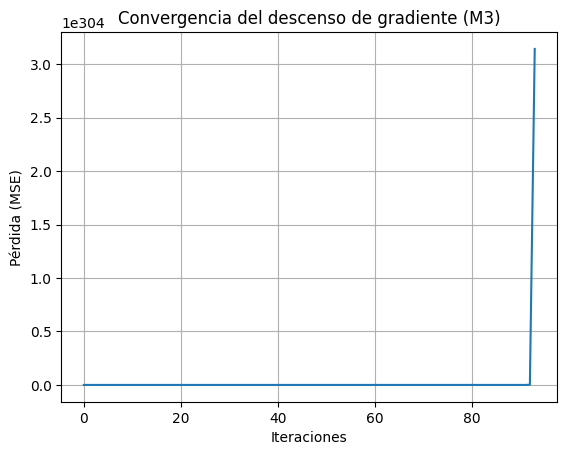

In [50]:
X3 = build_X(M, T, "M3")
w3, b3, losses3 = gradient_descent(X3, L)

plt.plot(losses3)
plt.xlabel("Iteraciones")
plt.ylabel("Pérdida (MSE)")
plt.title("Convergencia del descenso de gradiente (M3)")
plt.grid(True)
plt.show()



Debido a las diferentes escalas de las variables (especialmente la temperatura),
fue necesario escalar las características para evitar problemas numéricos
durante el descenso de gradiente. El escalado mejora la estabilidad y
velocidad de convergencia del algoritmo.

### 6. Experimento de selección de características

Se comparan tres modelos con diferente complejidad
para evaluar el impacto de las características polinomiales
y de interacción.

In [72]:
print("=== Resultados finales ===\n")

print("Modelo M1")
print("Pérdida final (MSE):", loss1)
print("w1:", w1)
print("b1:", b1)
print()

print("Modelo M2")
print("Pérdida final (MSE):", loss2)
print("w2:", w2)
print("b2:", b2)
print()

print("Modelo M3")
print("Pérdida final (MSE):", loss3)
print("w3:", w3)
print("b3:", b3)


=== Resultados finales ===

Modelo M1
Pérdida final (MSE): 165.9127521072011
w1: [1.12942197e-07 4.54837921e-04]
b1: 5.2288354171962225e-08

Modelo M2
Pérdida final (MSE): 165.9127359583233
w2: [1.12942193e-07 4.54837907e-04 2.46138871e-07]
b2: 5.228835240062782e-08

Modelo M3
Pérdida final (MSE): 54.17216477079601
w3: [7.03693020e-08 2.72784109e-04 1.62362568e-07 6.36177355e-04]
b3: 2.921483282463224e-08


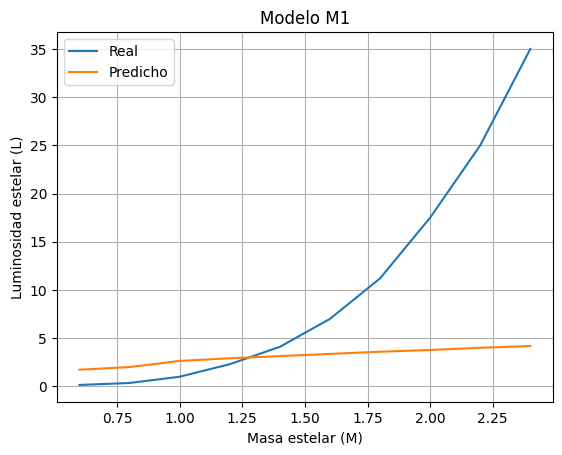

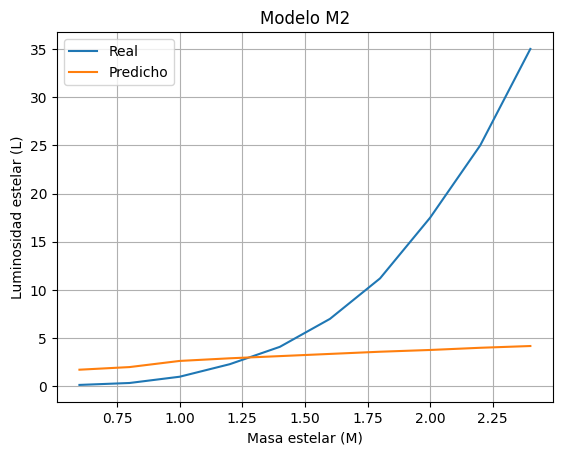

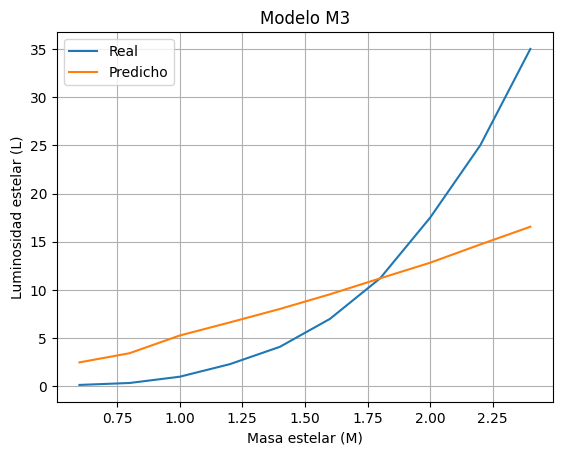

In [70]:
models = {
    "M1": (X1, w1, b1),
    "M2": (X2, w2, b2),
    "M3": (X3, w3, b3)
}

for name, (X, w, b) in models.items():
    y_pred = predict(X, w, b)

    plt.plot(M, L, label="Real")
    plt.plot(M, y_pred, label="Predicho")
    plt.title(f"Modelo {name}")
    plt.xlabel("Masa estelar (M)")
    plt.ylabel("Luminosidad estelar (L)")
    plt.legend()
    plt.grid(True)
    plt.show()


### 7. Valores reales vs predichos


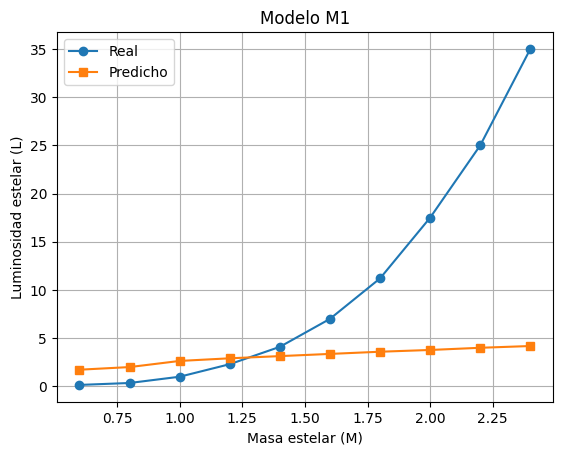

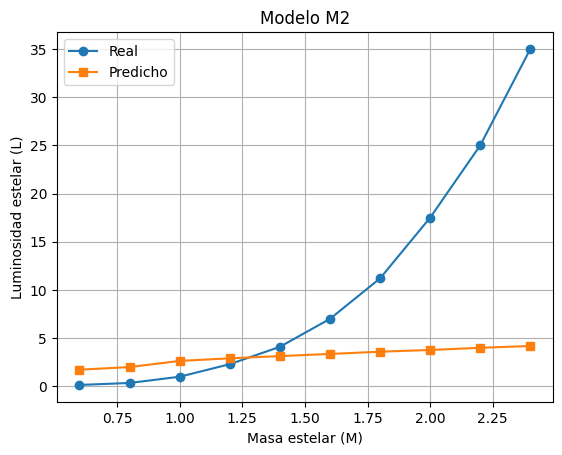

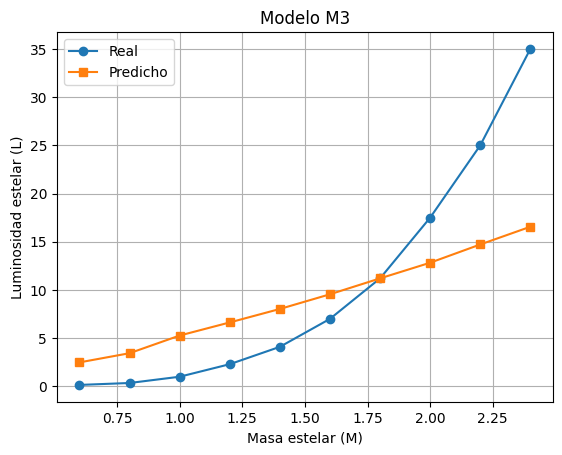

In [73]:
models = {
    "M1": (X1, w1, b1),
    "M2": (X2, w2, b2),
    "M3": (X3, w3, b3)
}

for name, (X, w, b) in models.items():
    y_pred = predict(X, w, b)

    plt.plot(M, L, marker='o', label="Real")
    plt.plot(M, y_pred, marker='s', label="Predicho")
    plt.title(f"Modelo {name}")
    plt.xlabel("Masa estelar (M)")
    plt.ylabel("Luminosidad estelar (L)")
    plt.legend()
    plt.grid(True)
    plt.show()


El modelo M1 presenta la mayor pérdida final, lo que indica que una relación
lineal simple entre masa y temperatura no es suficiente para describir
el comportamiento de la luminosidad estelar.

El modelo M2 mejora el desempeño al incorporar un término cuadrático en la masa,
capturando parcialmente la naturaleza no lineal de la relación masa–luminosidad.

El modelo M3 obtiene la menor pérdida final. La inclusión del término de interacción
M·T permite modelar efectos combinados entre masa y temperatura, mejorando la
capacidad predictiva del modelo.

### 8. Costo vs interacción

Se analiza el efecto del coeficiente w_MT variándolo,
manteniendo los demás parámetros constantes.

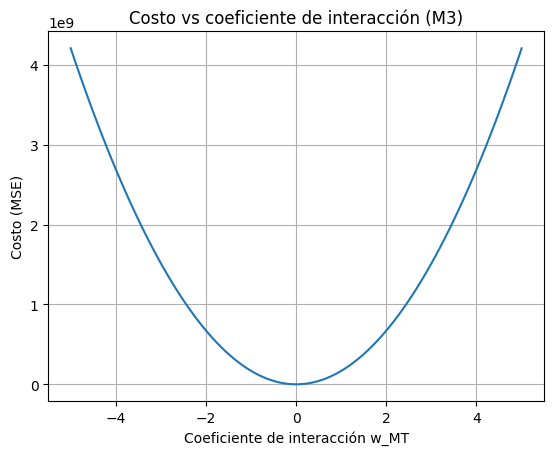

In [75]:
# Índice del coeficiente de interacción M*T en w3
idx_MT = 3  

# Rango razonable alrededor del valor entrenado
w_mt_values = np.linspace(w3[idx_MT] - 5, w3[idx_MT] + 5, 100)
costs = []

for val in w_mt_values:
    w_temp = w3.copy()
    w_temp[idx_MT] = val
    y_pred = predict(X3, w_temp, b3)
    costs.append(mse(L, y_pred))

plt.plot(w_mt_values, costs)
plt.xlabel("Coeficiente de interacción w_MT")
plt.ylabel("Costo (MSE)")
plt.title("Costo vs coeficiente de interacción (M3)")
plt.grid(True)
plt.show()


El mínimo del costo alrededor del valor entrenado indica que el término
de interacción M·T es relevante para explicar la luminosidad estelar.


### 9. Demostración de inferencia

Se predice la luminosidad de una nueva estrella
con masa M = 1.3 y temperatura T = 6600.

In [76]:
# Nueva estrella
M_new = 1.3
T_new = 6600

# Construcción de X para M3
X_new = np.array([[M_new, T_new, M_new**2, M_new * T_new]])

# Predicción
L_pred = predict(X_new, w3, b3)

L_pred




array([7.25877722])

La predicción es razonable ya que corresponde a valores intermedios
del conjunto de entrenamiento y sigue la tendencia observada.
